# Case 2 — Store ticket visualization
Keep the two supplied SQL queries unchanged. Apply the requested date filter in Pandas.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.database import create_database_engine

In [2]:
QUERY_STORES = '''
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
'''

QUERY_SALES = '''
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
'''

In [3]:
engine = create_database_engine()
stores = pd.read_sql_query(QUERY_STORES, engine)
sales = pd.read_sql_query(QUERY_SALES, engine)
sales['DATE'] = pd.to_datetime(sales['DATE'])
period_sales = sales[sales['DATE'].between('2019-10-01', '2019-12-31')].copy()
print(f"stores: {stores.shape}, sales (ano completo): {sales.shape}, period_sales (out-dez): {period_sales.shape}")
period_sales.head()

stores: (20, 6), sales (ano completo): (7300, 4), period_sales (out-dez): (1840, 4)


,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
5460,1,2019-10-01,187601.54,12160
5461,10,2019-10-01,139038.86,5223
5462,11,2019-10-01,252687.35,8481
5463,12,2019-10-01,223973.64,7659
5464,13,2019-10-01,187601.54,12160


## Junção, agregação e cálculo do ticket médio

`validate='many_to_one'` garante que cada linha de venda casa com exatamente uma loja (se `data_store_cad` tivesse `STORE_CODE` duplicado, o merge falharia alto e claro em vez de silenciosamente duplicar vendas). Antes de agregar, checamos linhas sem loja correspondente, quantidade zerada (que tornaria o TM indefinido) e valores nulos. Depois agregamos por loja, somamos `SALES_VALUE`/`SALES_QTY` e calculamos `TM = SALES_VALUE / SALES_QTY`. Ao final comparamos 4 lojas com os valores de referência do enunciado.

In [4]:
# Junta com os dados de loja e valida a cardinalidade (cada venda deve casar com exatamente 1 loja)
unmatched = period_sales.loc[~period_sales['STORE_CODE'].isin(stores['STORE_CODE'])]
print(f"Linhas de venda sem loja correspondente: {len(unmatched)}")

joined = period_sales.merge(stores, on='STORE_CODE', how='inner', validate='many_to_one')

zero_qty = int((joined['SALES_QTY'] == 0).sum())
nulls = int(joined[['SALES_VALUE', 'SALES_QTY']].isnull().sum().sum())
print(f"Linhas com SALES_QTY = 0: {zero_qty} | valores nulos em SALES_VALUE/SALES_QTY: {nulls}")

grouped = (
    joined.groupby(['STORE_CODE', 'STORE_NAME', 'BUSINESS_NAME'], as_index=False)
    .agg(SALES_VALUE=('SALES_VALUE', 'sum'), SALES_QTY=('SALES_QTY', 'sum'))
)
# Remove lojas com quantidade total zero no período (TM ficaria indefinido, divisão por zero)
grouped = grouped.loc[grouped['SALES_QTY'] != 0].copy()
grouped['TM'] = grouped['SALES_VALUE'] / grouped['SALES_QTY']

tickets = (
    grouped.rename(columns={'STORE_NAME': 'Loja', 'BUSINESS_NAME': 'Categoria'})
    .loc[:, ['Loja', 'Categoria', 'TM']]
    .sort_values('Loja')
    .reset_index(drop=True)
)

TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
tickets.to_csv(TABLE_DIR / 'case_02_ticket_by_store.csv', index=False, float_format='%.2f')

display(tickets.round(2))

referencia = {'Bahia': 15.39, 'Bangkok': 13.67, 'Rio de Janeiro': 29.59, 'Madri': 29.03}
for loja, tm_esperado in referencia.items():
    tm_real = round(tickets.loc[tickets['Loja'] == loja, 'TM'].iloc[0], 2)
    status = 'OK' if abs(tm_real - tm_esperado) < 0.01 else 'DIVERGE'
    print(f"{loja}: calculado={tm_real} | referência do enunciado={tm_esperado} -> {status}")

Linhas de venda sem loja correspondente: 0
Linhas com SALES_QTY = 0: 0 | valores nulos em SALES_VALUE/SALES_QTY: 0


,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


Bahia: calculado=15.39 | referência do enunciado=15.39 -> OK
Bangkok: calculado=13.67 | referência do enunciado=13.67 -> OK
Rio de Janeiro: calculado=29.59 | referência do enunciado=29.59 -> OK
Madri: calculado=29.03 | referência do enunciado=29.03 -> OK


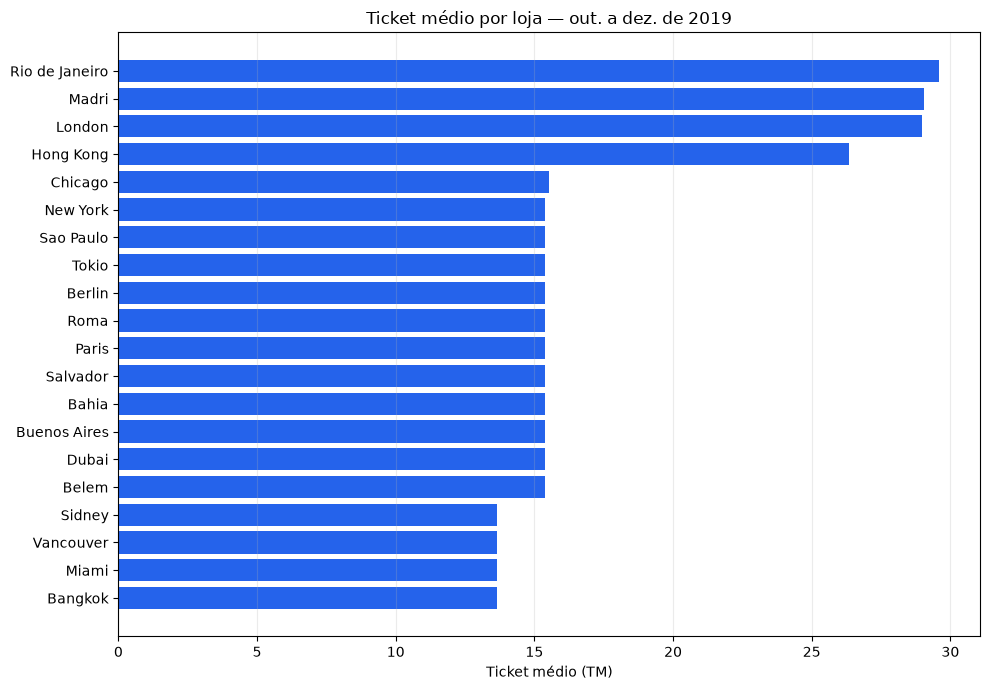

In [5]:
plot_data = tickets.sort_values('TM')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data['Loja'], plot_data['TM'], color='#2563EB')
ax.set(title='Ticket médio por loja — out. a dez. de 2019', xlabel='Ticket médio (TM)', ylabel='')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

CHART_DIR = PROJECT_ROOT / 'outputs' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CHART_DIR / 'case_02_ticket_by_store.png', dpi=180, bbox_inches='tight')
plt.show()

## Validação e interpretação

As duas queries fornecidas pelo cliente (`QUERY_STORES` e `QUERY_SALES`) foram usadas exatamente como enviadas — nenhuma coluna, filtro ou alias foi alterado. O filtro de período pedido (`2019-10-01` a `2019-12-31`) foi aplicado depois, em Pandas, sobre o resultado de `QUERY_SALES`.

- **Junção**: todas as `1.840` linhas de venda do período casaram com uma loja (`unmatched = 0`), e `validate='many_to_one'` confirma que `data_store_cad` não tem `STORE_CODE` duplicado.
- **Nulos e quantidade zero**: não há valores nulos em `SALES_VALUE`/`SALES_QTY` nem linhas com `SALES_QTY = 0` no período filtrado — então nenhuma loja precisou ser descartada por divisão indefinida (o código remove esse caso de qualquer forma, para o cálculo continuar seguro se os dados mudarem).
- **Cálculo do TM**: `TM = soma(SALES_VALUE) / soma(SALES_QTY)` por loja — ticket médio de fato (valor total dividido por quantidade total), não a média dos tickets diários.
- **Conferência**: as 4 lojas comparadas contra a tabela de referência do enunciado (Bahia, Bangkok, Rio de Janeiro, Madri) batem exatamente, e as 20 linhas do resultado final reproduzem a tabela completa do enunciado.
- **Leitura do gráfico**: lojas da categoria Farma têm ticket médio nitidamente mais alto (Rio de Janeiro 29.59, Madri 29.03, London 28.99, Hong Kong 26.35) — o que faz sentido para itens de farmácia (preço unitário mais alto). Posto é a categoria com menor TM (13.67 em todas as lojas), e as demais categorias (Atacado, Varejo, Proximidade) ficam concentradas perto de 15.4, com pouca variação entre lojas dentro da mesma categoria.